In [3]:
%pip install PyWavelets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


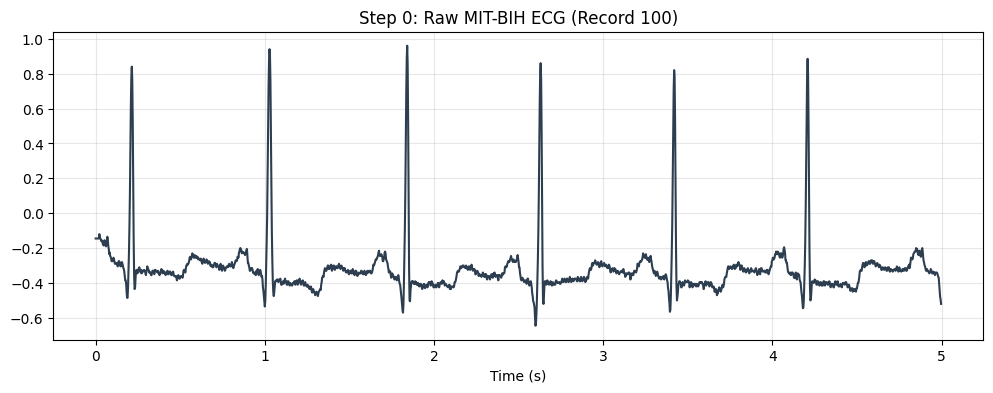

In [10]:
import wfdb
import pywt
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

# Notebook plotting setup
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

record_name = '100'
fs = 360 
seconds = 5 
total_samples = fs * seconds

print(f"Downloading MIT-BIH Record {record_name}...")
record = wfdb.rdsamp(record_name, pn_dir='mitdb', sampto=total_samples)

raw_signal = record[0][:, 0] 
t = np.arange(total_samples) / fs

plt.plot(t, raw_signal, color='#2c3e50')
plt.title(f"Step 0: Raw MIT-BIH ECG (Record {record_name})")
plt.xlabel("Time (s)")
plt.grid(True, alpha=0.3)
plt.show()

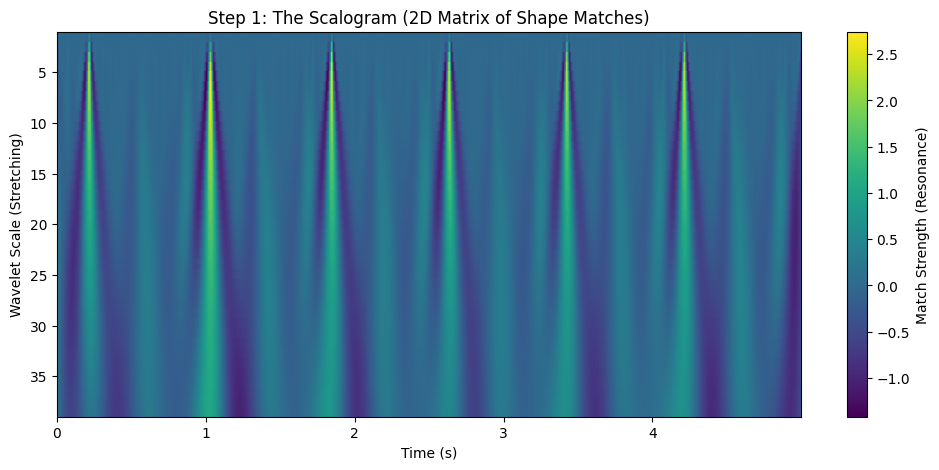

In [11]:
# Performing Continuous Wavelet Transform (CWT)
widths = np.arange(1, 40)

cwt_matrix, _ = pywt.cwt(raw_signal, widths, 'mexh')

plt.figure(figsize=(12, 5))
im = plt.imshow(cwt_matrix, extent=[t[0], t[-1], widths[-1], widths[0]], 
                cmap='viridis', aspect='auto', interpolation='nearest')
plt.title("Step 1: The Scalogram (2D Matrix of Shape Matches)")
plt.ylabel("Wavelet Scale (Stretching)")
plt.xlabel("Time (s)")
plt.colorbar(im, label="Match Strength (Resonance)")
plt.show()

The best matching wavelet width was: 15


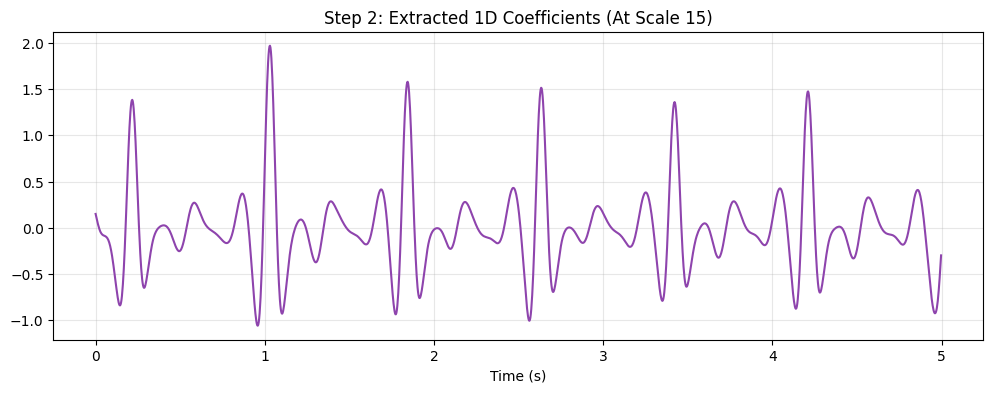

In [12]:
variance_across_scales = np.var(cwt_matrix, axis=1)
best_scale_idx = np.argmax(variance_across_scales)
best_coeffs = cwt_matrix[best_scale_idx]

print(f"The best matching wavelet width was: {widths[best_scale_idx]}")

plt.plot(t, best_coeffs, color='#8e44ad')
plt.title(f"Step 2: Extracted 1D Coefficients (At Scale {widths[best_scale_idx]})")
plt.xlabel("Time (s)")
plt.grid(True, alpha=0.3)
plt.show()

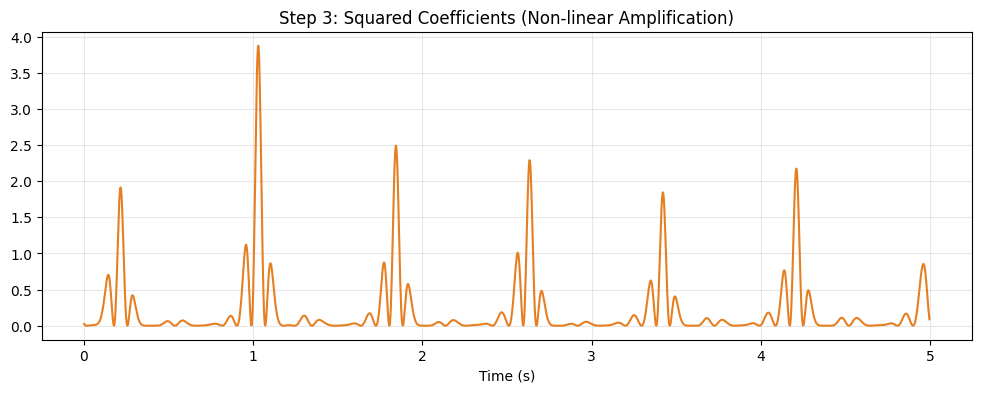

In [13]:
squared_coeffs = best_coeffs ** 2

plt.plot(t, squared_coeffs, color='#e67e22')
plt.title("Step 3: Squared Coefficients (Non-linear Amplification)")
plt.xlabel("Time (s)")
plt.grid(True, alpha=0.3)
plt.show()

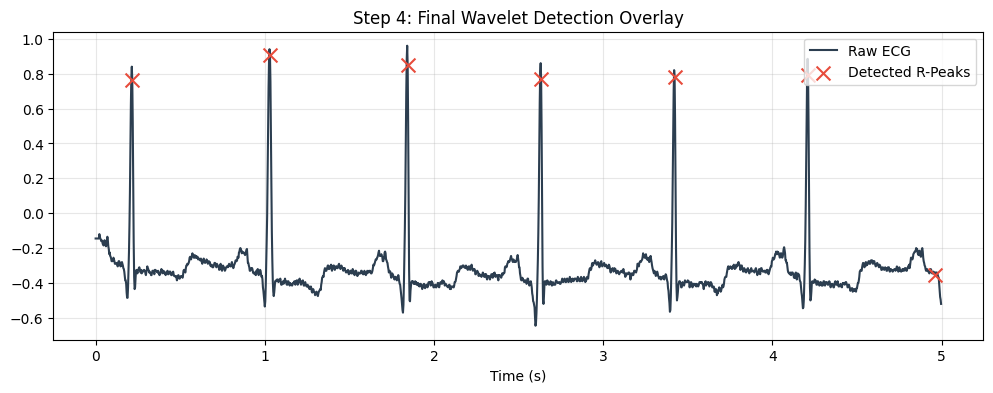

In [14]:
# minimum distance between beats (~300ms) to avoid double-counting
min_distance = int(0.3 * fs) 
# Setting basic threshold based on the signal's average energy
threshold = np.mean(squared_coeffs) * 1.5 

peaks, _ = signal.find_peaks(squared_coeffs, distance=min_distance, height=threshold)

plt.plot(t, raw_signal, color='#2c3e50', label="Raw ECG")
plt.scatter(t[peaks], raw_signal[peaks], marker='x', color='#e74c3c', s=100, zorder=5, label="Detected R-Peaks")

plt.title("Step 4: Final Wavelet Detection Overlay")
plt.xlabel("Time (s)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()